In [52]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from pprint import pprint
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tabulate import tabulate
import asyncio
import nest_asyncio

nest_asyncio.apply()

config = {
    "dataset":{
        "dti":"../../Data/scope_onside_common_v3.parquet",
        "adr":"../../Data/final_rxnorm_meddra_v2.parquet"
    },
    "protein_emb_1":{
        "path":  "../../Data/3. Protein_enbeddings/ESM_embeddings_(t33_650m model).parquet",
        "id_col": "id", 
        "emb_col": "embedding"
    },
    "protein_emb_2":{
        "path": "../../Data/3. Protein_enbeddings/GVP-GNN_protein_embeddings.parquet",
        "id_col": "uniprot_id", 
        "emb_col": "embedding"
    },
    "drug_emb_1":{
        "path": "../../Data/2. Drug_embeddings/EGNN_drug_embeddings_v2.parquet", 
        "id_col": "drug_chembl_id", 
        "emb_col": "embedding"
    },
    "drug_emb_2":{
        "path": "../../Data/2. Drug_embeddings/smiles_embeddings_chemberta.parquet", 
        "id_col": "drug_chembl_id", 
        "emb_col": "embedding"
    }
}

In [53]:
dti_df = pd.read_parquet(config["dataset"]["dti"])
print(dti_df.info())

# copy selected columns to a new df
# drug_chembl_id as drug_id and target_uniprot_id as protein_id
dti_df = dti_df.rename(columns={"drug_chembl_id": "drug_id", "target_uniprot_id": "protein_id"})

df = dti_df.copy()
df = df[["drug_id", "protein_id", "label", "rxcui"]]


if config["protein_emb_1"]["path"]:
    protein_emb_1_df = pd.read_parquet(config["protein_emb_1"]["path"])
    protein_emb_1_df = protein_emb_1_df.rename(columns={config["protein_emb_1"]["id_col"]: "protein_id"})
    df = df.merge(protein_emb_1_df[["protein_id", config["protein_emb_1"]["emb_col"]]], on="protein_id", how="left")
    df = df.rename(columns={config["protein_emb_1"]["emb_col"]: "prot_emb_1"})

if config["protein_emb_2"]["path"]:
    protein_emb_2_df = pd.read_parquet(config["protein_emb_2"]["path"])
    protein_emb_2_df = protein_emb_2_df.rename(columns={config["protein_emb_2"]["id_col"]: "protein_id"})
    df = df.merge(protein_emb_2_df[["protein_id", config["protein_emb_2"]["emb_col"]]], on="protein_id", how="left")
    df = df.rename(columns={config["protein_emb_2"]["emb_col"]: "prot_emb_2"})

if config["drug_emb_1"]["path"]:
    drug_emb_1_df = pd.read_parquet(config["drug_emb_1"]["path"])
    drug_emb_1_df = drug_emb_1_df.rename(columns={config["drug_emb_1"]["id_col"]: "drug_id"})
    df = df.merge(drug_emb_1_df[["drug_id", config["drug_emb_1"]["emb_col"]]], on="drug_id", how="left")
    df = df.rename(columns={config["drug_emb_1"]["emb_col"]: "drug_emb_1"})

if config["drug_emb_2"]["path"]:
    drug_emb_2_df = pd.read_parquet(config["drug_emb_2"]["path"])
    drug_emb_2_df = drug_emb_2_df.rename(columns={config["drug_emb_2"]["id_col"]: "drug_id"})
    df = df.merge(drug_emb_2_df[["drug_id", config["drug_emb_2"]["emb_col"]]], on="drug_id", how="left")
    df = df.rename(columns={config["drug_emb_2"]["emb_col"]: "drug_emb_2"})



print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34741 entries, 0 to 34740
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   drug_chembl_id     34741 non-null  object
 1   target_uniprot_id  34741 non-null  object
 2   label              34741 non-null  int64 
 3   smiles             34741 non-null  object
 4   sequence           34741 non-null  object
 5   molfile_3d         34741 non-null  object
 6   rxcui              34741 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.9+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34741 entries, 0 to 34740
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   drug_id     34741 non-null  object
 1   protein_id  34741 non-null  object
 2   label       34741 non-null  int64 
 3   rxcui       34741 non-null  object
 4   prot_emb_1  34741 non-null  object
 5   prot_emb_2  34741 non

In [54]:

class ADRData:
    def __init__(self, id_to_name_dict):
        """
        Initializes with a dictionary of {meddra_id: meddra_name}.
        """
        self.id_to_name = id_to_name_dict
        self.unique_ids = sorted(list(id_to_name_dict.keys()))
        
        self.id_to_idx = {adr_id: i for i, adr_id in enumerate(self.unique_ids)}
        self.idx_to_id = {i: adr_id for i, adr_id in enumerate(self.unique_ids)}
        
        self.vocab_size = len(self.unique_ids)

    def encode(self, adr_list):
        """
        Takes a list of ADR IDs and returns a binary vector (1s and 0s).
        Example: ['10028553', '10003041'] -> [0, 1, 0, 0, 1...]
        """
        vector = np.zeros(self.vocab_size, dtype=np.int8)
        
        for adr_id in adr_list:
            if adr_id in self.id_to_idx:
                idx = self.id_to_idx[adr_id]
                vector[idx] = 1
            else:
                print(f"Warning: ADR ID {adr_id} not in vocabulary.")
                
        return vector

    def decode(self, vector):
        """
        Takes a binary vector and returns a list of human-readable ADR names.
        """
        decoded_names = []
        
        active_indices = np.where(vector == 1)[0]
        
        for idx in active_indices:
            adr_id = self.idx_to_id[idx]
            name = self.id_to_name.get(adr_id, "Unknown ADR")
            decoded_names.append(name)
            
        return decoded_names

    def decode_indices(self, indices):
        """
        Takes a list or array of indices (e.g., [42, 105, 300]) 
        and returns the corresponding ADR names.
        """
        return [self.id_to_name.get(self.idx_to_id[idx], "Unknown ADR") for idx in indices]

    def decode_top_k(self, confidence_array, k=5):
        """
        Takes the raw probability array from the model, finds the top K 
        highest values, and returns names + their confidence scores.
        """
        # Get indices of the top k probabilities
        top_indices = np.argsort(confidence_array)[-k:][::-1]
        
        results = []
        for idx in top_indices:
            adr_id = self.idx_to_id[idx]
            name = self.id_to_name.get(adr_id, "Unknown ADR")
            conf = confidence_array[idx]
            results.append({"name": name, "confidence": round(float(conf), 4)})
            
        return results

    def decode_with_threshold(self, confidence_array, threshold=0.5):
        """
        Returns all ADRs that pass a specific confidence threshold.
        Useful for seeing everything the model is "sure" about.
        """
        active_indices = np.where(confidence_array >= threshold)[0]
        
        # Sort them by confidence (highest first)
        active_indices = active_indices[np.argsort(confidence_array[active_indices])[::-1]]
        
        return [self.id_to_name.get(self.idx_to_id[idx], "Unknown ADR") for idx in active_indices]


In [55]:
adrdf = pd.read_parquet(config['dataset']["adr"])
id_name_dict = dict(zip(adrdf['meddra_id'], adrdf['meddra_name']))
adr_manager = ADRData(id_name_dict)

In [56]:
drug_to_adr_list = adrdf.groupby('rxnorm_ingredient_id')['meddra_id'].apply(list).to_dict()

def get_encoded_adr(drug_id):
    # Get the list of ADRs for this drug, or an empty list if not found
    adrs = drug_to_adr_list.get(drug_id, [])
    return adr_manager.encode(adrs)

# 2. Map the drug_id (e.g., rxcui) to the encoded vector
# This will create a column where each cell is a numpy array
df['adr'] = df['rxcui'].map(get_encoded_adr)
print(f"Total rows with ADRs: {df['adr'].apply(lambda x: x.sum() > 0).sum()}")

Total rows with ADRs: 34741


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34741 entries, 0 to 34740
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   drug_id     34741 non-null  object
 1   protein_id  34741 non-null  object
 2   label       34741 non-null  int64 
 3   rxcui       34741 non-null  object
 4   prot_emb_1  34741 non-null  object
 5   prot_emb_2  34741 non-null  object
 6   drug_emb_1  34741 non-null  object
 7   drug_emb_2  34741 non-null  object
 8   adr         34741 non-null  object
dtypes: int64(1), object(8)
memory usage: 2.4+ MB


In [58]:
from sklearn.model_selection import train_test_split

# 1. Get all unique protein IDs
unique_proteins = df['protein_id'].unique()

# 2. Split protein IDs (not rows) to ensure no leakage
# We'll reserve 10% of proteins for Test and 10% for Validation
train_prot_ids, temp_prot_ids = train_test_split(
    unique_proteins, 
    test_size=0.20, 
    random_state=42
)

val_prot_ids, test_prot_ids = train_test_split(
    temp_prot_ids, 
    test_size=0.50, 
    random_state=42
)

# 3. Create the dataframes based on these ID splits
train_df = df[df['protein_id'].isin(train_prot_ids)]
val_df = df[df['protein_id'].isin(val_prot_ids)]
test_df = df[df['protein_id'].isin(test_prot_ids)]

# --- Verification & Metrics ---
print(f"--- Final Dataset Sizes ---")
print(f"Train Set: {len(train_df)} rows ({len(train_prot_ids)} proteins)")
print(f"Val Set:   {len(val_df)} rows ({len(val_prot_ids)} proteins) - [Model Selection]")
print(f"Test Set:  {len(test_df)} rows ({len(test_prot_ids)} proteins) - [Cold-Protein Eval]")

# 4. Recalculate Positive Weight for Training
num_neg = (train_df['label'] == 0).sum()
num_pos = (train_df['label'] == 1).sum()

# Avoid division by zero just in case
pos_weight_value = num_neg / num_pos if num_pos > 0 else 1.0

print(f"\nNew Positive Weight: {pos_weight_value:.2f}")
print(f"Positive/Negative Ratio in Train: 1:{num_neg/num_pos:.2f}")

--- Final Dataset Sizes ---
Train Set: 28055 rows (1908 proteins)
Val Set:   3335 rows (238 proteins) - [Model Selection]
Test Set:  3351 rows (239 proteins) - [Cold-Protein Eval]

New Positive Weight: 1.75
Positive/Negative Ratio in Train: 1:1.75


In [59]:
class FusionModule(nn.Module):
    def __init__(self, dim1, dim2, output_dim):
        super().__init__()
        self.fusion = nn.Sequential(
            nn.Linear(dim1 + dim2, output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
    def forward(self, e1, e2):
        return self.fusion(torch.cat([e1, e2], dim=1))

class DTIModel(nn.Module):
    """DTI-only model: Drug-Protein context → DTI prediction (No ADR)"""
    def __init__(self, drug_dims, prot_dims, fused_dim=768, dti_hidden=256):
        super().__init__()
        
        # 1. Fusion Layers (Drug-Protein context only)
        self.drug_fusion = FusionModule(drug_dims[0], drug_dims[1], fused_dim)
        self.prot_fusion = FusionModule(prot_dims[0], prot_dims[1], fused_dim)
        
        # 2. Context Encoder (processes only drug-protein interaction)
        encoder_input_dim = fused_dim * 2 
        self.context_encoder = nn.Sequential(
            nn.Linear(encoder_input_dim, 1024), 
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # 3. DTI Head (Direct DTI prediction from context)
        self.dti_head = nn.Sequential(
            nn.Linear(512, dti_hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(dti_hidden, 1)
        )

    def forward(self, d1, d2, p1, p2):
        # Only processes drug-protein context
        fused_drug = self.drug_fusion(d1, d2) 
        fused_prot = self.prot_fusion(p1, p2)
        
        # Concatenate drug-protein context
        context_input = torch.cat([fused_drug, fused_prot], dim=1)
        context = self.context_encoder(context_input)
        
        # DTI prediction only (keep shape [batch_size, 1] for loss compatibility)
        dti_logits = self.dti_head(context)
        
        return dti_logits


class DeepDTA(nn.Module):
    """DeepDTA model for DTI prediction
    Paper: Deep Drug-Target Binding Affinity Prediction
    Adapted for embedding-based inputs
    """
    def __init__(self, drug_dims, prot_dims, hidden_dim=512, latent_dim=256, dropout=0.2):
        super().__init__()
        
        # Drug representation processing
        self.drug_fc = nn.Sequential(
            nn.Linear(drug_dims[0] + drug_dims[1], hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        # Protein representation processing
        self.prot_fc = nn.Sequential(
            nn.Linear(prot_dims[0] + prot_dims[1], hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        # DTI prediction head
        self.dti_head = nn.Sequential(
            nn.Linear(latent_dim * 2, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )
    
    def forward(self, d1, d2, p1, p2):
        # Concatenate embedding pairs
        drug_rep = torch.cat([d1, d2], dim=1)
        prot_rep = torch.cat([p1, p2], dim=1)
        
        # Process through respective networks
        drug_feat = self.drug_fc(drug_rep)
        prot_feat = self.prot_fc(prot_rep)
        
        # Concatenate features for DTI head (keep shape [batch_size, 1] for loss compatibility)
        combined = torch.cat([drug_feat, prot_feat], dim=1)
        dti_logits = self.dti_head(combined)
        
        return dti_logits


In [60]:
# DTI-only loss function (no ADR)
def compute_dti_loss(dti_logits, dti_labels, pos_weight, device='cpu'):
    """Binary cross-entropy loss for DTI task only (Drug-Protein interaction)"""
    # Reshape labels to match logits shape [batch_size, 1]
    labels_reshaped = dti_labels.unsqueeze(1) if dti_labels.dim() == 1 else dti_labels
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))
    # BCEWithLogitsLoss accepts [batch_size, 1] directly
    return criterion(dti_logits, labels_reshaped)

In [61]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    precision_recall_curve, auc, precision_score, recall_score, average_precision_score
)

def evaluate_dti(model, dataloader, device):
    """Evaluate DTI head only (Drug-Protein interaction, no ADR)"""
    model.eval()
    
    dti_true, dti_probs = [], []

    with torch.no_grad():
        for d1, d2, p1, p2, labels, adr_targets in dataloader:
            d1 = d1.to(device, non_blocking=True)
            d2 = d2.to(device, non_blocking=True)
            p1 = p1.to(device, non_blocking=True)
            p2 = p2.to(device, non_blocking=True)
            
            # Forward pass - only DTI prediction (no ADR)
            dti_logits = model(d1, d2, p1, p2)  # Shape: [batch_size, 1]
            
            # Convert to probabilities, flatten to 1D
            dti_p = torch.sigmoid(dti_logits).cpu().numpy().flatten()
            
            dti_true.extend(labels.numpy())
            dti_probs.extend(dti_p)

    # DTI METRICS
    dti_true = np.array(dti_true)
    dti_probs = np.array(dti_probs).flatten()
    dti_preds = (dti_probs > 0.5).astype(int)

    # Calculate Precision-Recall AUC (AUPRC)
    precision_pts, recall_pts, _ = precision_recall_curve(dti_true, dti_probs)
    auprc = auc(recall_pts, precision_pts)

    results = {
        "Accuracy": accuracy_score(dti_true, dti_preds),
        "F1": f1_score(dti_true, dti_preds),
        "Precision": precision_score(dti_true, dti_preds),
        "Recall": recall_score(dti_true, dti_preds),
        "AUROC": roc_auc_score(dti_true, dti_probs),
        "AUPRC": auprc
    }

    return results, dti_probs, dti_true


In [62]:
class DTIVAE_Dataset(Dataset):
    """
    Optimized: converts dataframe columns to contiguous torch tensors ONCE in __init__.
    Avoids per-sample torch.tensor(...) calls (major CPU bottleneck).
    """
    def __init__(self, dataframe):
        df = dataframe.reset_index(drop=True)

        def _stack_float(col_name):
            # Converts an object column (lists/np arrays) into a 2D float32 numpy array
            arrs = df[col_name].to_numpy()
            # robust conversion: each row -> np.asarray(float32)
            arrs = [np.asarray(a, dtype=np.float32) for a in arrs]
            return np.stack(arrs, axis=0)

        def _stack_adr(col_name="adr"):
            arrs = df[col_name].to_numpy()
            # adr vectors are int8/0-1; convert to float32 once
            arrs = [np.asarray(a, dtype=np.float32) for a in arrs]
            return np.stack(arrs, axis=0)

        # Inputs
        self.d1 = torch.from_numpy(_stack_float("drug_emb_1"))
        self.d2 = torch.from_numpy(_stack_float("drug_emb_2"))
        self.p1 = torch.from_numpy(_stack_float("prot_emb_1"))
        self.p2 = torch.from_numpy(_stack_float("prot_emb_2"))

        # Targets
        self.labels = torch.from_numpy(df["label"].to_numpy(dtype=np.float32))
        self.adr = torch.from_numpy(_stack_adr("adr"))

    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, idx):
        # No new tensor creation here — just indexing contiguous tensors
        return (
            self.d1[idx],
            self.d2[idx],
            self.p1[idx],
            self.p2[idx],
            self.labels[idx],
            self.adr[idx],
        )


In [63]:
import os
import torch
from torch.utils.data import DataLoader

# Detect Jupyter / IPython
def _in_notebook():
    try:
        from IPython import get_ipython
        return get_ipython() is not None and "IPKernelApp" in get_ipython().config
    except Exception:
        return False

pin = torch.cuda.is_available()

# Windows + Jupyter: multi-worker DataLoader frequently crashes due to spawn/pickling issues
if os.name == "nt" and _in_notebook():
    num_workers = 0
    persistent = False
    prefetch = None
else:
    cpu = os.cpu_count() or 4
    num_workers = min(8, max(2, cpu - 2))
    persistent = (num_workers > 0)
    prefetch = 4

train_loader = DataLoader(
    DTIVAE_Dataset(train_df),
    batch_size=64,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin,
    persistent_workers=persistent,
    prefetch_factor=prefetch
)

val_loader = DataLoader(
    DTIVAE_Dataset(val_df),
    batch_size=64,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin,
    persistent_workers=persistent,
    prefetch_factor=prefetch
)

test_loader = DataLoader(
    DTIVAE_Dataset(test_df),
    batch_size=64,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin,
    persistent_workers=persistent,
    prefetch_factor=prefetch
)

print(f"DataLoader: num_workers={num_workers}, pin_memory={pin}, persistent_workers={persistent}, prefetch_factor={prefetch}")


DataLoader: num_workers=0, pin_memory=True, persistent_workers=False, prefetch_factor=None


In [64]:
def train_dti_model(model, train_loader, val_loader, test_loader, pos_weight, epochs=50, lr=1e-3, device='cuda', model_name='DTI_Model'):
    """
    Train DTI-only model (Drug-Protein interaction, no ADR)
    
    Args:
        model: DTI model to train
        train_loader: Training data loader
        val_loader: Validation data loader
        test_loader: Test data loader
        pos_weight: Positive class weight for imbalanced data
        epochs: Number of training epochs
        lr: Learning rate
        device: Device to use (cuda/cpu)
        model_name: Name for saving checkpoints
    """
    model.to(device)
    
    # Optimizer and scheduler
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(
        optimizer, 
        mode='max', 
        patience=5, 
        factor=0.5,
        min_lr=1e-6, 
    )
    
    best_val_auroc = -1
    best_val_auprc = -1
    training_history = {
        'train_loss': [],
        'val_auroc': [],
        'val_auprc': [],
        'val_f1': []
    }
    
    print(f"\n{'='*80}")
    print(f"Training DTI Model: {model_name}")
    print(f"{'='*80}")
    print(f"Device: {device} | LR: {lr} | Pos Weight: {pos_weight:.2f}\n")
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        # Training loop
        for d1, d2, p1, p2, labels, adr_targets in train_loader:
            d1 = d1.to(device, non_blocking=True)
            d2 = d2.to(device, non_blocking=True)
            p1 = p1.to(device, non_blocking=True)
            p2 = p2.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            
            # Forward pass - DTI only
            dti_logits = model(d1, d2, p1, p2)
            
            # Compute DTI loss
            loss = compute_dti_loss(dti_logits, labels, pos_weight, device=device)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_losses.append(loss.detach().cpu().item())
        
        # Validation
        val_metrics, _, _ = evaluate_dti(model, val_loader, device)
        test_metrics, _, _ = evaluate_dti(model, test_loader, device)
        
        mean_train_loss = np.mean(train_losses)
        training_history['train_loss'].append(mean_train_loss)
        training_history['val_auroc'].append(val_metrics['AUROC'])
        training_history['val_auprc'].append(val_metrics['AUPRC'])
        training_history['val_f1'].append(val_metrics['F1'])
        
        # Update scheduler based on AUPRC
        scheduler.step(val_metrics['AUPRC'])
        
        # Checkpointing
        if val_metrics['AUPRC'] > best_val_auprc:
            best_val_auprc = val_metrics['AUPRC']
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            is_best = "✓ BEST"
        else:
            is_best = ""
        
        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {mean_train_loss:.4f} | " +
                  f"Val AUROC: {val_metrics['AUROC']:.4f} | Val AUPRC: {val_metrics['AUPRC']:.4f} | " +
                  f"Val F1: {val_metrics['F1']:.4f} {is_best}")
    
    print(f"\n{'='*80}")
    print(f"Training Complete! Best Val AUPRC: {best_val_auprc:.4f}")
    print(f"{'='*80}\n")
    
    return model, training_history


In [65]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

sample_row = train_df.iloc[0]

# Detect Drug Dimensions
d1_dim = len(sample_row['drug_emb_1'])
d2_dim = len(sample_row['drug_emb_2'])

# Detect Protein Dimensions
p1_dim = len(sample_row['prot_emb_1'])
p2_dim = len(sample_row['prot_emb_2'])

# Detect ADR Dimension (not needed for DTI-only, but keep for reference)
num_adrs = adr_manager.vocab_size

print(f"--- Detected Dimensions ---")
print(f"Drug Inputs: {d1_dim}, {d2_dim}")
print(f"Protein Inputs: {p1_dim}, {p2_dim}")
print(f"ADR Output: {num_adrs} (for reference only - NOT used in DTI-only model)")

# --- INITIALIZE DTI-ONLY MODELS ---
print(f"\n{'='*80}")
print("Initializing DTI Models (Drug-Protein context ONLY - No ADR)")
print(f"{'='*80}\n")

# 1. Your DTI Model
dti_model = DTIModel(
    drug_dims=[d1_dim, d2_dim], 
    prot_dims=[p1_dim, p2_dim], 
    fused_dim=1028,
    dti_hidden=256
).to(device)

print(f"✓ DTIModel initialized")
print(f"  Parameters: {sum(p.numel() for p in dti_model.parameters()):,}")

# 2. DeepDTA Model
deepdta_model = DeepDTA(
    drug_dims=[d1_dim, d2_dim], 
    prot_dims=[p1_dim, p2_dim], 
    hidden_dim=512,
    latent_dim=256,
    dropout=0.2
).to(device)

print(f"✓ DeepDTA initialized")
print(f"  Parameters: {sum(p.numel() for p in deepdta_model.parameters()):,}")

print(f"\n{'='*80}")
print("Ready for DTI-only training and comparison!")
print(f"{'='*80}\n")


Using device: cuda
--- Detected Dimensions ---
Drug Inputs: 256, 384
Protein Inputs: 1280, 1024
ADR Output: 4817 (for reference only - NOT used in DTI-only model)

Initializing DTI Models (Drug-Protein context ONLY - No ADR)

✓ DTIModel initialized
  Parameters: 5,795,353
✓ DeepDTA initialized
  Parameters: 2,165,249

Ready for DTI-only training and comparison!



In [66]:
import os
import sys
sys.path.append(os.path.abspath(".."))
from training_monitor import TrainingMonitor

In [67]:
# ============================================================================
# DTI-ONLY MODEL TRAINING & COMPARISON
# ============================================================================
# Train DTI models and compare their performance on Drug-Protein interactions

print("\n" + "="*80)
print("TRAINING DTI MODELS - Drug-Protein Context ONLY (No ADR)")
print("="*80)

# Train DTI Model
dti_model_trained, dti_history = train_dti_model(
    model=dti_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    pos_weight=pos_weight_value,
    epochs=30,
    lr=1e-3,
    device=device,
    model_name="DTI_Model"
)

# Train DeepDTA Model
deepdta_trained, deepdta_history = train_dti_model(
    model=deepdta_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    pos_weight=pos_weight_value,
    epochs=30,
    lr=1e-3,
    device=device,
    model_name="DeepDTA"
)

print("✓ DTI model training completed successfully!")



TRAINING DTI MODELS - Drug-Protein Context ONLY (No ADR)

Training DTI Model: DTI_Model
Device: cuda | LR: 0.001 | Pos Weight: 1.75

Epoch   1/30 | Train Loss: 0.6348 | Val AUROC: 0.8806 | Val AUPRC: 0.7180 | Val F1: 0.7119 ✓ BEST
Epoch   5/30 | Train Loss: 0.5209 | Val AUROC: 0.8958 | Val AUPRC: 0.7504 | Val F1: 0.7190 
Epoch  10/30 | Train Loss: 0.4839 | Val AUROC: 0.8579 | Val AUPRC: 0.6894 | Val F1: 0.6521 
Epoch  15/30 | Train Loss: 0.4639 | Val AUROC: 0.9006 | Val AUPRC: 0.7832 | Val F1: 0.7144 
Epoch  20/30 | Train Loss: 0.4508 | Val AUROC: 0.8977 | Val AUPRC: 0.7650 | Val F1: 0.7008 
Epoch  25/30 | Train Loss: 0.4136 | Val AUROC: 0.9054 | Val AUPRC: 0.7820 | Val F1: 0.7227 
Epoch  30/30 | Train Loss: 0.3964 | Val AUROC: 0.9039 | Val AUPRC: 0.7821 | Val F1: 0.7243 

Training Complete! Best Val AUPRC: 0.7958


Training DTI Model: DeepDTA
Device: cuda | LR: 0.001 | Pos Weight: 1.75

Epoch   1/30 | Train Loss: 0.6199 | Val AUROC: 0.8747 | Val AUPRC: 0.7069 | Val F1: 0.7023 ✓ BEST


In [68]:
# ============================================================================
# COMPARE DTI MODELS ON TEST SET
# ============================================================================

print("\n" + "="*80)
print("EVALUATING DTI MODELS ON TEST SET")
print("="*80 + "\n")

# Evaluate both models
dti_test_metrics, dti_probs, dti_true = evaluate_dti(dti_model_trained, test_loader, device)
deepdta_test_metrics, deepdta_probs, deepdta_true = evaluate_dti(deepdta_trained, test_loader, device)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    "DTI Model": dti_test_metrics,
    "DeepDTA": deepdta_test_metrics
}).T

print("\n" + "="*80)
print("DTI MODELS PERFORMANCE COMPARISON (Test Set)")
print("="*80 + "\n")
print(comparison_df.round(4))

# Identify best model
print("\n" + "="*80)
print("BEST PERFORMERS BY METRIC:")
print("="*80)
for metric in comparison_df.columns:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"{metric:.<30} {best_model:.<20} ({best_value:.4f})")

# Store results for visualization
comparison_results = {
    "DTI Model": {
        "metrics": dti_test_metrics,
        "predictions": dti_probs,
        "ground_truth": dti_true
    },
    "DeepDTA": {
        "metrics": deepdta_test_metrics,
        "predictions": deepdta_probs,
        "ground_truth": deepdta_true
    }
}

print("\n✓ DTI model comparison completed!")



EVALUATING DTI MODELS ON TEST SET


DTI MODELS PERFORMANCE COMPARISON (Test Set)

           Accuracy      F1  Precision  Recall   AUROC   AUPRC
DTI Model    0.8433  0.7767     0.7345  0.8240  0.9157  0.8534
DeepDTA      0.8421  0.7650     0.7533  0.7771  0.9111  0.8391

BEST PERFORMERS BY METRIC:
Accuracy...................... DTI Model........... (0.8433)
F1............................ DTI Model........... (0.7767)
Precision..................... DeepDTA............. (0.7533)
Recall........................ DTI Model........... (0.8240)
AUROC......................... DTI Model........... (0.9157)
AUPRC......................... DTI Model........... (0.8534)

✓ DTI model comparison completed!


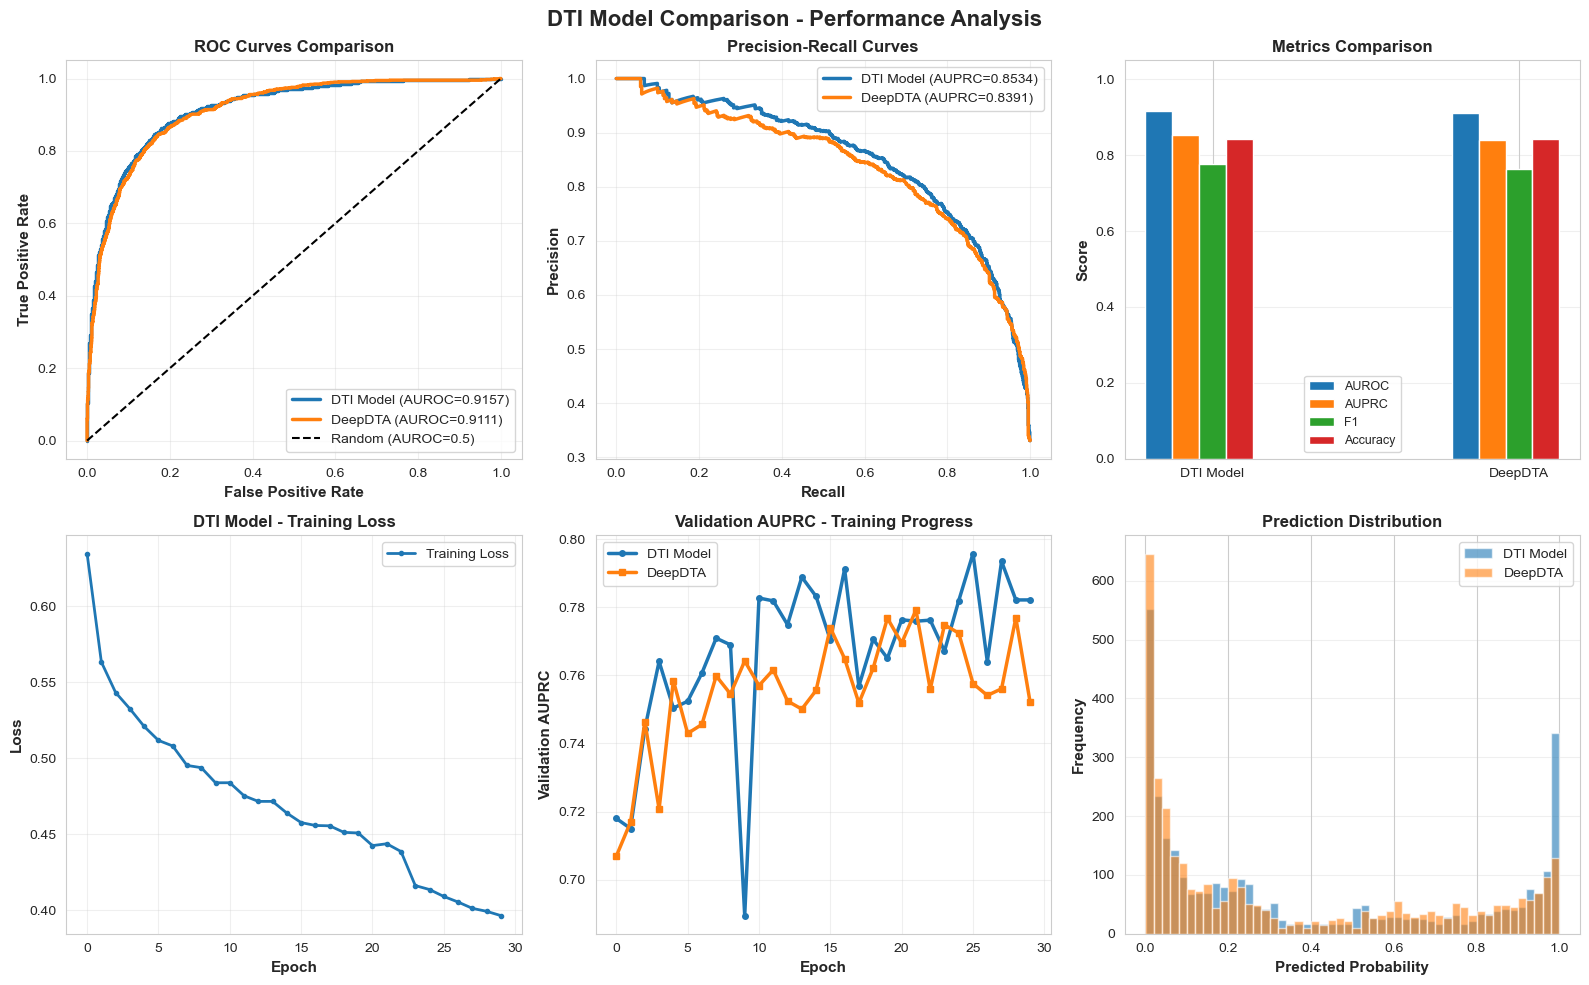

✓ Visualizations generated successfully!


In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, precision_recall_curve

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('DTI Model Comparison - Performance Analysis', fontsize=16, fontweight='bold')

# 1. ROC CURVES
ax = axes[0, 0]
for model_name, result in comparison_results.items():
    y_true = result["ground_truth"]
    y_probs = result["predictions"]
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    auroc = result["metrics"]["AUROC"]
    ax.plot(fpr, tpr, label=f"{model_name} (AUROC={auroc:.4f})", linewidth=2.5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random (AUROC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax.set_title('ROC Curves Comparison', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

# 2. PRECISION-RECALL CURVES
ax = axes[0, 1]
for model_name, result in comparison_results.items():
    y_true = result["ground_truth"]
    y_probs = result["predictions"]
    precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_probs)
    auprc = result["metrics"]["AUPRC"]
    ax.plot(recall_pts, precision_pts, label=f"{model_name} (AUPRC={auprc:.4f})", linewidth=2.5)

ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax.set_title('Precision-Recall Curves', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# 3. METRICS COMPARISON BAR CHART
ax = axes[0, 2]
metrics_to_plot = ["AUROC", "AUPRC", "F1", "Accuracy"]
x = np.arange(len(comparison_results))
width = 0.35

for i, metric in enumerate(metrics_to_plot):
    values = [comparison_results[m]["metrics"][metric] for m in comparison_results.keys()]
    ax.bar(x + i*width/len(metrics_to_plot), values, width/len(metrics_to_plot), label=metric)

ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('Metrics Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x + width/2)
ax.set_xticklabels(comparison_results.keys())
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.05])

# 4. TRAINING HISTORY - DTI Model Loss
ax = axes[1, 0]
ax.plot(dti_history['train_loss'], label='Training Loss', linewidth=2, marker='o', markersize=3)
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax.set_title('DTI Model - Training Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 5. TRAINING HISTORY - AUPRC
ax = axes[1, 1]
ax.plot(dti_history['val_auprc'], label='DTI Model', linewidth=2.5, marker='o', markersize=4)
ax.plot(deepdta_history['val_auprc'], label='DeepDTA', linewidth=2.5, marker='s', markersize=4)
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Validation AUPRC', fontsize=11, fontweight='bold')
ax.set_title('Validation AUPRC - Training Progress', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 6. PREDICTION DISTRIBUTION
ax = axes[1, 2]
for model_name, result in comparison_results.items():
    ax.hist(result["predictions"], bins=50, alpha=0.6, label=model_name)

ax.set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Prediction Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Visualizations generated successfully!")

In [71]:
# ============================================================================
# DETAILED STATISTICAL ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("DETAILED DTI MODEL ANALYSIS")
print("="*80)

# Prediction distribution analysis
print("\nPREDICTION DISTRIBUTION ANALYSIS:")
print("-" * 80)

for model_name, result in comparison_results.items():
    predictions = result["predictions"]
    print(f"\n{model_name}:")
    print(f"  Mean prediction:     {predictions.mean():.4f}")
    print(f"  Std deviation:       {predictions.std():.4f}")
    print(f"  Min prediction:      {predictions.min():.4f}")
    print(f"  Max prediction:      {predictions.max():.4f}")
    print(f"  Median:              {np.median(predictions):.4f}")
    print(f"  Predictions > 0.5:   {(predictions > 0.5).sum()} ({(predictions > 0.5).mean()*100:.1f}%)")

# Calibration analysis
print("\n" + "="*80)
print("CALIBRATION ANALYSIS (Expected vs Observed):")
print("="*80)

def analyze_calibration(y_true, y_probs, n_bins=10):
    """Analyze prediction calibration"""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    calibration_data = []
    
    for i in range(n_bins):
        mask = (y_probs >= bin_edges[i]) & (y_probs < bin_edges[i + 1])
        if mask.sum() > 0:
            expected = (bin_edges[i] + bin_edges[i + 1]) / 2
            observed = y_true[mask].mean()
            count = mask.sum()
            calibration_data.append({
                'bin': i + 1,
                'expected': expected,
                'observed': observed,
                'count': count
            })
    
    return pd.DataFrame(calibration_data)

for model_name, result in comparison_results.items():
    y_true = result["ground_truth"]
    y_probs = result["predictions"]
    
    calib_df = analyze_calibration(y_true, y_probs)
    print(f"\n{model_name}:")
    print(calib_df.to_string(index=False))

# Error analysis
print("\n" + "="*80)
print("ERROR ANALYSIS:")
print("="*80)

for model_name, result in comparison_results.items():
    y_true = result["ground_truth"]
    y_probs = result["predictions"]
    y_preds = (y_probs > 0.5).astype(int)
    
    tp = ((y_preds == 1) & (y_true == 1)).sum()
    tn = ((y_preds == 0) & (y_true == 0)).sum()
    fp = ((y_preds == 1) & (y_true == 0)).sum()
    fn = ((y_preds == 0) & (y_true == 1)).sum()
    
    print(f"\n{model_name}:")
    print(f"  True Positives:      {tp:,}")
    print(f"  True Negatives:      {tn:,}")
    print(f"  False Positives:     {fp:,}")
    print(f"  False Negatives:     {fn:,}")
    print(f"  Total Samples:       {len(y_true):,}")

print("\n✓ Detailed analysis completed!")



DETAILED DTI MODEL ANALYSIS

PREDICTION DISTRIBUTION ANALYSIS:
--------------------------------------------------------------------------------

DTI Model:
  Mean prediction:     0.3888
  Std deviation:       0.3739
  Min prediction:      0.0002
  Max prediction:      1.0000
  Median:              0.2295
  Predictions > 0.5:   1243 (37.1%)

DeepDTA:
  Mean prediction:     0.3468
  Std deviation:       0.3544
  Min prediction:      0.0001
  Max prediction:      1.0000
  Median:              0.1885
  Predictions > 0.5:   1143 (34.1%)

CALIBRATION ANALYSIS (Expected vs Observed):

DTI Model:
 bin  expected  observed  count
   1      0.05  0.027004   1185
   2      0.15  0.103723    376
   3      0.25  0.175074    337
   4      0.35  0.269841    126
   5      0.45  0.369048     84
   6      0.55  0.411765    170
   7      0.65  0.551181    127
   8      0.75  0.556522    115
   9      0.85  0.705263    190
  10      0.95  0.896063    635

DeepDTA:
 bin  expected  observed  count
   1     

In [72]:
# ============================================================================
# SAVE & EXPORT DTI COMPARISON RESULTS
# ============================================================================

import json
import os

# Create results directory
os.makedirs('dti_comparison_results', exist_ok=True)

# 1. Save comparison metrics to JSON
results_summary = {}
for model_name, result in comparison_results.items():
    results_summary[model_name] = {
        "metrics": {k: float(v) for k, v in result["metrics"].items()},
        "prediction_stats": {
            "mean": float(result["predictions"].mean()),
            "std": float(result["predictions"].std()),
            "min": float(result["predictions"].min()),
            "max": float(result["predictions"].max()),
            "median": float(np.median(result["predictions"])),
            "positive_ratio": float((result["predictions"] > 0.5).mean())
        }
    }

output_json = 'dti_comparison_results/dti_comparison_metrics.json'
with open(output_json, 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f"✓ Results saved to {output_json}")

# 2. Export comparison to CSV
comparison_df_export = comparison_df.copy()
comparison_df_export.to_csv('dti_comparison_results/dti_comparison_metrics.csv')
print(f"✓ Metrics exported to dti_comparison_results/dti_comparison_metrics.csv")

# 3. Save training history
training_summary = {
    "DTI_Model": dti_history,
    "DeepDTA": deepdta_history
}

# Convert numpy to native Python types for JSON serialization
def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convert_to_serializable(item) for item in obj]
    return obj

training_summary_serializable = convert_to_serializable(training_summary)

output_training = 'dti_comparison_results/training_history.json'
with open(output_training, 'w') as f:
    json.dump(training_summary_serializable, f, indent=2)
print(f"✓ Training history saved to {output_training}")

# 4. Print final summary
print("\n" + "="*80)
print("DTI MODELS COMPARISON - FINAL SUMMARY")
print("="*80)

print(f"\nDataset Information:")
print(f"  Test Samples:        {len(dti_true):,}")
print(f"  Positive Samples:    {int(dti_true.sum()):,} ({dti_true.mean()*100:.1f}%)")
print(f"  Negative Samples:    {int((1-dti_true).sum()):,} ({(1-dti_true).mean()*100:.1f}%)")

print(f"\nKey Findings (Drug-Protein Context ONLY - No ADR):")
print("-" * 80)

best_auroc_model = comparison_df.loc[:, "AUROC"].idxmax()
best_auprc_model = comparison_df.loc[:, "AUPRC"].idxmax()
best_f1_model = comparison_df.loc[:, "F1"].idxmax()
best_accuracy_model = comparison_df.loc[:, "Accuracy"].idxmax()

print(f"✓ Best AUROC:     {best_auroc_model:.<40} {comparison_df.loc[best_auroc_model, 'AUROC']:.4f}")
print(f"✓ Best AUPRC:     {best_auprc_model:.<40} {comparison_df.loc[best_auprc_model, 'AUPRC']:.4f}")
print(f"✓ Best F1:        {best_f1_model:.<40} {comparison_df.loc[best_f1_model, 'F1']:.4f}")
print(f"✓ Best Accuracy:  {best_accuracy_model:.<40} {comparison_df.loc[best_accuracy_model, 'Accuracy']:.4f}")

print(f"\nExported Files:")
print(f"  - dti_comparison_results/dti_comparison_metrics.json")
print(f"  - dti_comparison_results/dti_comparison_metrics.csv")
print(f"  - dti_comparison_results/training_history.json")
print(f"  - best_DTI_Model.pth (model weights)")
print(f"  - best_DeepDTA.pth (model weights)")

print(f"\n{'='*80}")
print("✓ DTI Comparison Complete!")
print(f"{'='*80}\n")


✓ Results saved to dti_comparison_results/dti_comparison_metrics.json
✓ Metrics exported to dti_comparison_results/dti_comparison_metrics.csv
✓ Training history saved to dti_comparison_results/training_history.json

DTI MODELS COMPARISON - FINAL SUMMARY

Dataset Information:
  Test Samples:        3,351
  Positive Samples:    1,108 (33.1%)
  Negative Samples:    2,243 (66.9%)

Key Findings (Drug-Protein Context ONLY - No ADR):
--------------------------------------------------------------------------------
✓ Best AUROC:     DTI Model............................... 0.9157
✓ Best AUPRC:     DTI Model............................... 0.8534
✓ Best F1:        DTI Model............................... 0.7767
✓ Best Accuracy:  DTI Model............................... 0.8433

Exported Files:
  - dti_comparison_results/dti_comparison_metrics.json
  - dti_comparison_results/dti_comparison_metrics.csv
  - dti_comparison_results/training_history.json
  - best_DTI_Model.pth (model weights)
  - best_D